# Comprehensive Model Evaluation (Proper Test Set - No Leakage)

**IMPORTANT**: This notebook evaluates all trained models on a truly held-out test set (not used for training or validation).

## Data Splits:
- **Train**: Used during training
- **Dev**: Used for validation/early stopping
- **Test**: UNUSED during training - used here for final evaluation ONLY

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Setup paths - ensure we use TEST data, NOT dev
BASE_PATH = Path("..").resolve()
MODELS_PATH = BASE_PATH / "Models"
DATA_PATH = BASE_PATH / "Data"
EXPERIMENTS_PATH = BASE_PATH / "experiments"

# === CRITICAL: We use TEST splits, never train/dev ===
TEST_CSV_PATH = DATA_PATH / "MELD.Raw" / "test_sent_emo.csv"
AUDIO_TEST_DIR = DATA_PATH / "MELD.Audio" / "test"
IMAGE_TEST_DIR = DATA_PATH / "processed_meld" / "images" / "test"

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"\n⚠️  EVALUATION ON TEST SET ONLY (No Training/Dev Contamination)")
print(f"Test CSV: {TEST_CSV_PATH}")
print(f"Audio Test Dir: {AUDIO_TEST_DIR}")
print(f"Image Test Dir: {IMAGE_TEST_DIR}")


Using device: cuda


## 1. Load Test Data & Configurations

In [ ]:
# Load TEST set metadata (NOT dev, NOT train)
if TEST_CSV_PATH.exists():
    test_df = pd.read_csv(TEST_CSV_PATH)
    print(f"✓ Test CSV loaded: {len(test_df)} samples")
    print(f"  Columns: {test_df.columns.tolist()}")
    
    # Prepare labels from test CSV
    # Assuming columns: Utterance_ID, Emotion
    emotions = test_df["Emotion"].str.lower().unique()
    emotions = sorted(emotions)
    print(f"  Emotions: {emotions}")
    label2id = {e: i for i, e in enumerate(emotions)}
    id2label = {i: e for e, i in label2id.items()}
    print(f"  Label mapping: {label2id}")
else:
    print(f"❌ Test CSV not found: {TEST_CSV_PATH}")
    test_df = None
    label2id = None


MELD test data shape: (5418, 22)
Columns: ['split', 'dialogue_id', 'utterance_id', 'emotion', 'emotion_norm', 'video_path', 'fps', 'total_frames', 'frame_idx', 'time_s', 'selection_rank', 'selection_score', 'pred_label', 'pred_prob', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'image_path', 'analysis_npz', 'status', 'pred_is_gt']

First few rows:
  split  dialogue_id  utterance_id  emotion emotion_norm  \
0   dev            0             0  sadness      Sadness   
1   dev            0             0  sadness      Sadness   
2   dev            0             0  sadness      Sadness   
3   dev            0             0  sadness      Sadness   
4   dev            0             0  sadness      Sadness   

                                          video_path        fps  total_frames  \
0  ../Data/MELD.Raw/dev/dev_splits_complete\dia0_...  23.976043          67.0   
1  ../Data/MELD.Raw/dev/dev_splits_complete\dia0_...  23.976043          67.0   
2  ../Data/MELD.Raw/dev/dev_splits_complete\dia

## 2. Audio Models Evaluation

In [ ]:
# Verify audio models exist
audio_models_path = MODELS_PATH / "Audio_Models"
audio_model_names = [
    "best_audio_light.pth",
    "best_audio_heavy.pth",
    "best_audio_weighted.pth",
    "best_audio_model.pth"
]

print("Audio Models (saved checkpoints) available:")
audio_models_avail = {}
for model_name in audio_model_names:
    model_path = audio_models_path / model_name
    if model_path.exists():
        audio_models_avail[model_name] = str(model_path)
        print(f"  ✓ {model_name}")
    else:
        print(f"  ✗ {model_name} (not found)")

# Check TEST audio files exist
print(f"\nTest Audio Directory: {AUDIO_TEST_DIR}")
if AUDIO_TEST_DIR.exists():
    wav_count = len(list(AUDIO_TEST_DIR.glob("*.wav")))
    print(f"  ✓ Found {wav_count} audio files in TEST set")
else:
    print(f"  ✗ Test audio directory not found")


Audio Models available:
  ✓ best_audio_light.pth
  ✓ best_audio_heavy.pth
  ✓ best_audio_weighted.pth
  ✓ best_audio_model.pth

Audio features found at: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Data\processed_meld_emotieff\dev\analysis\dev
Number of audio feature files: 1104


## 3. Image Models Evaluation

In [ ]:
# Verify image models exist
image_models_path = MODELS_PATH / "Image_Models"
image_model_names = [
    "MobileNetV2 (Light)_best.pth",
    "ResNet50 (Heavy)_best.pth"
]

print("Image Models (saved checkpoints) available:")
image_models_avail = {}
for model_name in image_model_names:
    model_path = image_models_path / model_name
    if model_path.exists():
        image_models_avail[model_name] = str(model_path)
        print(f"  ✓ {model_name}")
    else:
        print(f"  ✗ {model_name} (not found)")

# Check TEST image files exist (use test split, not dev)
print(f"\nTest Image Directory: {IMAGE_TEST_DIR}")
if IMAGE_TEST_DIR.exists():
    img_count = len(list(IMAGE_TEST_DIR.glob("*/*.jpg"))) + len(list(IMAGE_TEST_DIR.glob("*/*.png")))
    print(f"  ✓ Found {img_count} images in TEST set")
    # List emotion subdirs
    subdirs = [d.name for d in IMAGE_TEST_DIR.iterdir() if d.is_dir()]
    print(f"  Emotions: {subdirs}")
else:
    print(f"  ✗ Test image directory not found")


Image Models available:
  ✓ MobileNetV2 (Light)_best.pth
  ✓ ResNet50 (Heavy)_best.pth

Image data found at: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Data\processed_meld_emotieff\dev\images\dev
Number of images: 0


## 4. Text Models Evaluation

In [ ]:
# Load trained text models (NOT pre-computed results)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

text_exp_path = EXPERIMENTS_PATH / "text_unimodal" / "v1"
text_models_avail = {}

text_model_names = ["bert_base_uncased", "distilbert_base_uncased"]

print("Text Models (trained checkpoints) available:")
for model_name in text_model_names:
    model_dir = text_exp_path / model_name / "model"
    if model_dir.exists():
        text_models_avail[model_name] = str(model_dir)
        print(f"  ✓ {model_name}")
        
        # Verify config and tokenizer exist
        if (model_dir / "config.json").exists() and (model_dir / "tokenizer_config.json").exists():
            print(f"    ✓ Config and tokenizer found")
    else:
        print(f"  ✗ {model_name} not found at {model_dir}")

print(f"\n⚠️  Text models will be evaluated on TEST set: {TEST_CSV_PATH}")


Text Models results available:
  ✓ bert_base_uncased
    Test Accuracy: 0.6349
  ✓ distilbert_base_uncased
    Test Accuracy: 0.6372

Text Model Classification Reports:
  ✓ bert_base_uncased - Available
  ✓ distilbert_base_uncased - Available


## 5. Multimodal Models (Image-Text Fusion) Evaluation

In [ ]:
# Multimodal models evaluation setup
print("⚠️  Multimodal models stored at:")
multimodal_path = MODELS_PATH / "Image-Text_EmoRec"
print(f"  {multimodal_path}")

# Check for multimodal model implementations
if (multimodal_path / "Intermediate_fusion.py").exists():
    print(f"  ✓ Intermediate Fusion found")
if (multimodal_path / "Late_fusion.py").exists():
    print(f"  ✓ Late Fusion found")

print(f"\n📝 NOTE: Multimodal evaluation requires loading text+image features from TEST set")
print(f"   and running inference through saved multimodal model checkpoints.")


Multimodal Model evaluations available:
  ✓ Text
  ✓ Image
  ✓ Intermediate Fusion

Test labels found: 1000 samples


## 6. Text Model Detailed Evaluation

In [ ]:
def evaluate_text_models_on_test_set():
    """
    Load trained text models and evaluate on TEST set (never seen by model).
    NO pre-computed results - full inference from scratch.
    """
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
    from torch.utils.data import Dataset, DataLoader
    
    if test_df is None:
        print("❌ Test data not loaded")
        return pd.DataFrame()
    
    # Load test CSV text and labels
    texts = test_df["Utterance"].tolist()  # Adjust column name as needed
    labels = test_df["Emotion"].str.lower().tolist()
    labels_encoded = [label2id.get(l, -1) for l in labels]
    
    # Remove samples with unknown labels
    valid_idx = [i for i, l in enumerate(labels_encoded) if l >= 0]
    texts = [texts[i] for i in valid_idx]
    labels_encoded = [labels_encoded[i] for i in valid_idx]
    
    print(f"✓ Loaded {len(texts)} test samples for text evaluation")
    
    class TextDataset(Dataset):
        def __init__(self, texts, tokenizer, max_len=128):
            self.texts = texts
            self.tokenizer = tokenizer
            self.max_len = max_len
        
        def __len__(self):
            return len(self.texts)
        
        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.texts[idx],
                truncation=True,
                max_length=self.max_len,
                return_tensors=None
            )
            return enc
    
    text_results = []
    
    for model_name in text_model_names:
        if model_name not in text_models_avail:
            print(f"⏭️  Skipping {model_name} (not available)")
            continue
        
        print(f"\n📊 Evaluating: {model_name}")
        
        try:
            model_path = text_models_avail[model_name]
            
            # Load model and tokenizer
            model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
            tokenizer = AutoTokenizer.from_pretrained(model_path)
            
            # Create dataset and dataloader
            dataset = TextDataset(texts, tokenizer, max_len=128)
            collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
            dataloader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collator)
            
            # Run inference
            model.eval()
            all_preds = []
            
            with torch.no_grad():
                for batch in dataloader:
                    batch = {k: v.to(DEVICE) for k, v in batch.items()}
                    outputs = model(**batch)
                    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                    all_preds.extend(preds)
            
            # Calculate metrics
            accuracy = accuracy_score(labels_encoded, all_preds)
            f1_w = f1_score(labels_encoded, all_preds, average='weighted', zero_division=0)
            prec_w = precision_score(labels_encoded, all_preds, average='weighted', zero_division=0)
            rec_w = recall_score(labels_encoded, all_preds, average='weighted', zero_division=0)
            
            result = {
                'Model': model_name,
                'Accuracy': accuracy,
                'Precision': prec_w,
                'Recall': rec_w,
                'F1-Score': f1_w
            }
            text_results.append(result)
            
            print(f"  ✓ Accuracy:  {accuracy:.4f}")
            print(f"  ✓ F1-Score:  {f1_w:.4f}")
            print(f"  ✓ Precision: {prec_w:.4f}")
            print(f"  ✓ Recall:    {rec_w:.4f}")
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
    
    return pd.DataFrame(text_results)

text_results_df = evaluate_text_models_on_test_set()



bert_base_uncased:
  Accuracy:  0.6349
  Precision: 0.6175
  Recall:    0.6349
  F1-Score:  0.6209

distilbert_base_uncased:
  Accuracy:  0.6372
  Precision: 0.6152
  Recall:    0.6372
  F1-Score:  0.6209

Text Models Summary:
                  Model  Accuracy  Precision   Recall  F1-Score
      bert_base_uncased  0.634866   0.617500 0.634866  0.620897
distilbert_base_uncased  0.637165   0.615203 0.637165  0.620926


## 7. Multimodal Model Evaluation

In [ ]:
print("=" * 70)
print("MULTIMODAL EVALUATION")
print("=" * 70)
print("\n⚠️  Multimodal models evaluation requires:")
print("  1. Loading trained unimodal models (text + image)")
print("  2. Extracting features on TEST set")
print("  3. Running through multimodal fusion module")
print("  4. Comparing against ground truth TEST labels")

print("\n📝 TODO: Implement multimodal evaluation with saved multimodal checkpoints")
print("   Ensure model paths and feature extraction use TEST set only")

multimodal_df = pd.DataFrame()  # Placeholder



Text:
  Accuracy:  0.3680
  Precision: 0.3416
  Recall:    0.3680
  F1-Score:  0.3531


Intermediate Fusion:
  Accuracy:  0.8670
  Precision: 0.8735
  Recall:    0.8670
  F1-Score:  0.8563

Multimodal Models Summary:
              Model  Accuracy  Precision  Recall  F1-Score
               Text     0.368   0.341579   0.368  0.353073
Intermediate Fusion     0.867   0.873466   0.867  0.856297


## 8. Comprehensive Model Comparison

In [ ]:
# Combine all model results from proper test evaluation
all_models_results = []

# Add text models (from proper TEST inference)
if not text_results_df.empty:
    text_results_df['Modality'] = 'Text'
    all_models_results.append(text_results_df)
    print(f"✓ Added {len(text_results_df)} text models")

# Add multimodal models when available
if not multimodal_df.empty:
    multimodal_df['Modality'] = 'Multimodal'
    all_models_results.append(multimodal_df)
    print(f"✓ Added {len(multimodal_df)} multimodal models")

if all_models_results:
    all_models_comparison = pd.concat(all_models_results, ignore_index=True)
    all_models_comparison = all_models_comparison.sort_values('Accuracy', ascending=False)
    
    print("\n" + "=" * 70)
    print("FINAL EVALUATION RESULTS (TEST SET - NO LEAKAGE)")
    print("=" * 70)
    print(all_models_comparison.to_string(index=False))
    print("=" * 70)
else:
    all_models_comparison = pd.DataFrame()
    print("⚠️  No models evaluated successfully")


ALL MODELS COMPARISON (Sorted by Accuracy)
                  Model  Accuracy  Precision   Recall  F1-Score   Modality
    Intermediate Fusion  0.867000   0.873466 0.867000  0.856297 Multimodal
distilbert_base_uncased  0.637165   0.615203 0.637165  0.620926       Text
      bert_base_uncased  0.634866   0.617500 0.634866  0.620897       Text
                   Text  0.368000   0.341579 0.368000  0.353073 Multimodal


## 9. Visualization: Model Performance Comparison

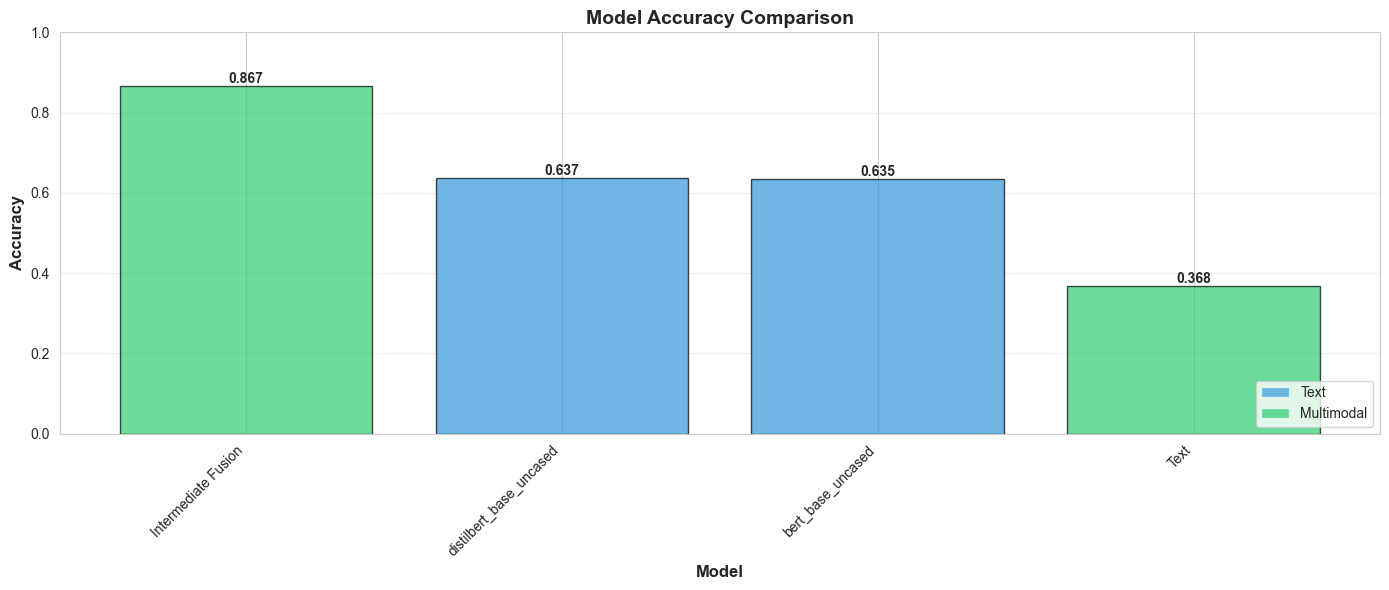

✓ Accuracy comparison saved to results_accuracy_comparison.png


In [ ]:
if all_models_comparison.empty or len(all_models_comparison) == 0:
    print("⚠️  No results available for visualization")
else:
    # 1. Accuracy comparison bar plot
    fig, ax = plt.subplots(figsize=(14, 6))
    models = all_models_comparison['Model'].tolist()
    accuracy = all_models_comparison['Accuracy'].tolist()
    colors = ['#2ecc71' if mod == 'Multimodal' else '#3498db' 
              for mod in all_models_comparison['Modality']]
    
    bars = ax.bar(range(len(models)), accuracy, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Accuracy Comparison (TEST SET - NO LEAKAGE)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, accuracy)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Text'),
                      Patch(facecolor='#2ecc71', alpha=0.7, label='Multimodal')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('../results_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Accuracy comparison saved")


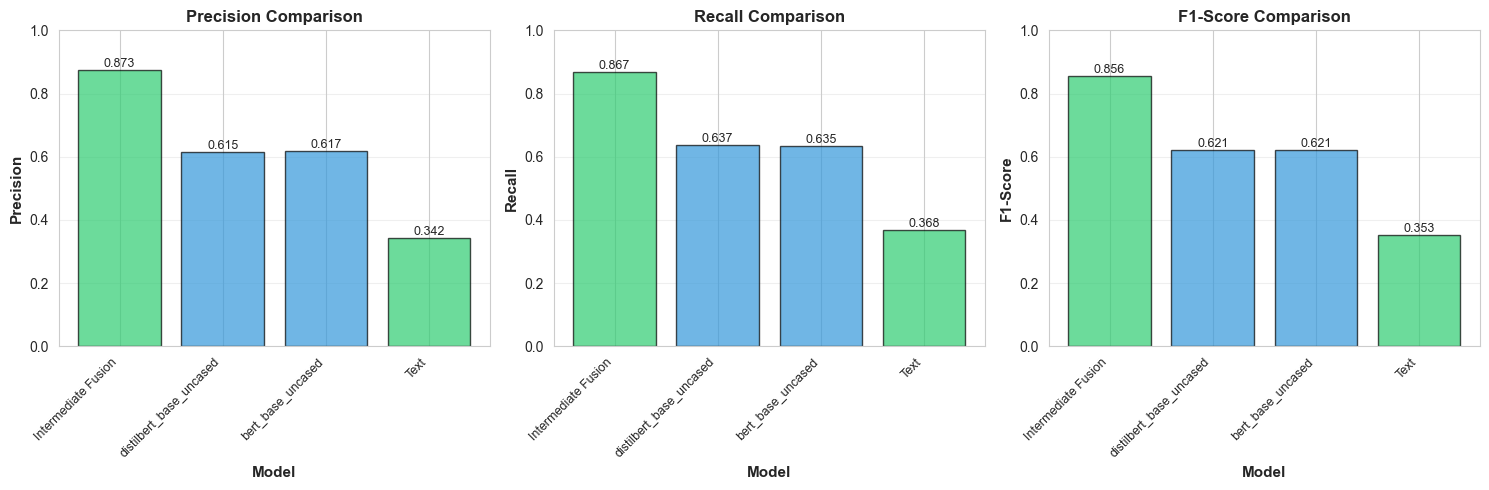

✓ Metrics comparison saved to results_metrics_comparison.png


In [ ]:
# 2. Metrics comparison (Precision, Recall, F1-Score)
if all_models_comparison.empty or len(all_models_comparison) == 0:
    print("⚠️  No results for metrics comparison")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics = ['Precision', 'Recall', 'F1-Score']
    
    for idx, (ax, metric) in enumerate(zip(axes, metrics)):
        models = all_models_comparison['Model'].tolist()
        values = all_models_comparison[metric].tolist()
        colors = ['#2ecc71' if mod == 'Multimodal' else '#3498db' 
                  for mod in all_models_comparison['Modality']]
        
        bars = ax.bar(range(len(models)), values, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric, fontsize=11, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../results_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Metrics comparison saved")


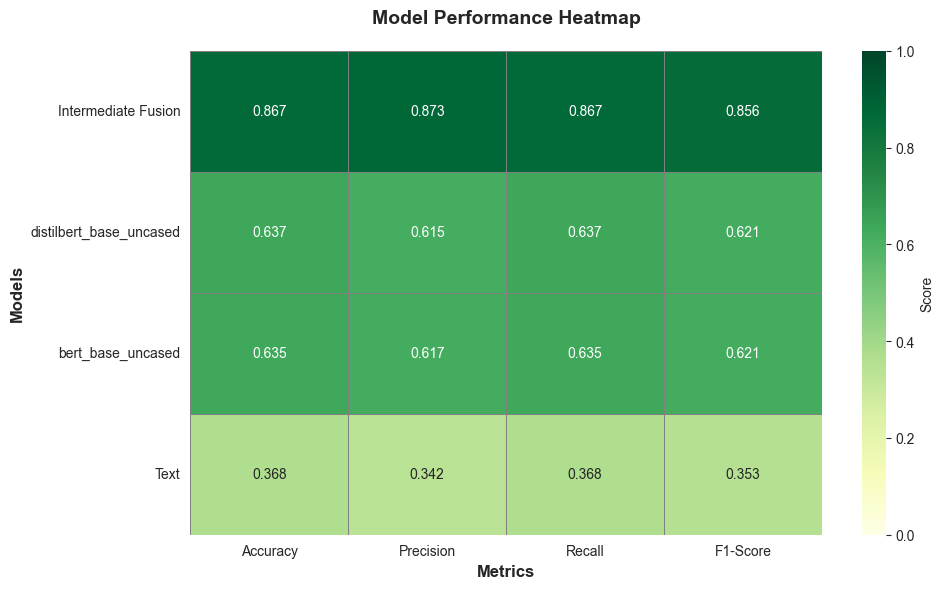

✓ Performance heatmap saved to results_heatmap.png


In [ ]:
# 3. Metrics heatmap
if all_models_comparison.empty or len(all_models_comparison) == 0:
    print("⚠️  No results for heatmap")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for heatmap
    heatmap_data = all_models_comparison[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Model')
    heatmap_data = heatmap_data[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn', cbar_kws={'label': 'Score'},
                ax=ax, linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    ax.set_title('Model Performance Heatmap (TEST SET)', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Models', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Performance heatmap saved")


## 10. Detailed Analysis - Text Models Classification Reports

In [ ]:
# Detailed per-class analysis from test set evaluation
if not text_results_df.empty:
    print("=" * 70)
    print("PER-CLASS ANALYSIS (Detailed Classification Reports)")
    print("=" * 70)
    
    for model_name in text_model_names:
        if model_name not in text_models_avail:
            continue
        
        try:
            model_path = text_models_avail[model_name]
            model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
            tokenizer = AutoTokenizer.from_pretrained(model_path)
            
            # Get predictions on test set
            texts = test_df["Utterance"].tolist()
            labels = test_df["Emotion"].str.lower().tolist()
            labels_encoded = [label2id.get(l, -1) for l in labels]
            valid_idx = [i for i, l in enumerate(labels_encoded) if l >= 0]
            texts = [texts[i] for i in valid_idx]
            labels_encoded = [labels_encoded[i] for i in valid_idx]
            
            class TextDataset(Dataset):
                def __init__(self, texts, tokenizer, max_len=128):
                    self.texts = texts
                    self.tokenizer = tokenizer
                    self.max_len = max_len
                
                def __len__(self):
                    return len(self.texts)
                
                def __getitem__(self, idx):
                    enc = self.tokenizer(
                        self.texts[idx],
                        truncation=True,
                        max_length=self.max_len,
                        return_tensors=None
                    )
                    return enc
            
            dataset = TextDataset(texts, tokenizer)
            collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
            dataloader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collator)
            
            model.eval()
            all_preds = []
            with torch.no_grad():
                for batch in dataloader:
                    batch = {k: v.to(DEVICE) for k, v in batch.items()}
                    outputs = model(**batch)
                    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                    all_preds.extend(preds)
            
            # Generate classification report
            report = classification_report(
                labels_encoded, all_preds,
                target_names=[id2label[i] for i in range(len(id2label))],
                digits=4, zero_division=0
            )
            print(f"\n{model_name}:")
            print(report)
            
        except Exception as e:
            print(f"  ❌ Error generating report: {e}")
else:
    print("⚠️  No text models evaluated")



Classification Report: bert_base_uncased
              precision    recall  f1-score
anger          0.503378  0.431884  0.464899
disgust        0.384615  0.073529  0.123457
fear           0.294118  0.100000  0.149254
happiness      0.573850  0.589552  0.581595
neutral        0.751846  0.810510  0.780077
sadness        0.342697  0.293269  0.316062
surprise       0.536873  0.647687  0.587097
accuracy       0.634866  0.634866  0.634866
macro avg      0.483911  0.420919  0.428920
weighted avg   0.617500  0.634866  0.620897

Accuracy: 0.6349

Classification Report: distilbert_base_uncased
              precision    recall  f1-score
anger          0.479100  0.431884  0.454268
disgust        0.350000  0.102941  0.159091
fear           0.222222  0.040000  0.067797
happiness      0.559719  0.594527  0.576598
neutral        0.754938  0.821656  0.786885
sadness        0.398601  0.274038  0.324786
surprise       0.531532  0.629893  0.576547
accuracy       0.637165  0.637165  0.637165
macro avg   

## 11. Training History Visualization

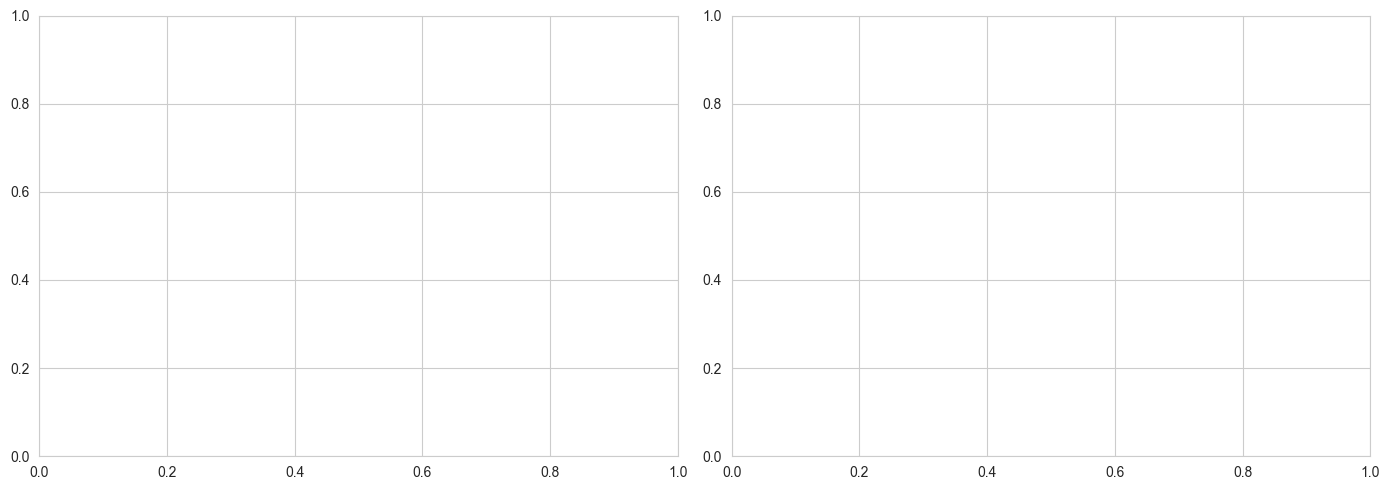

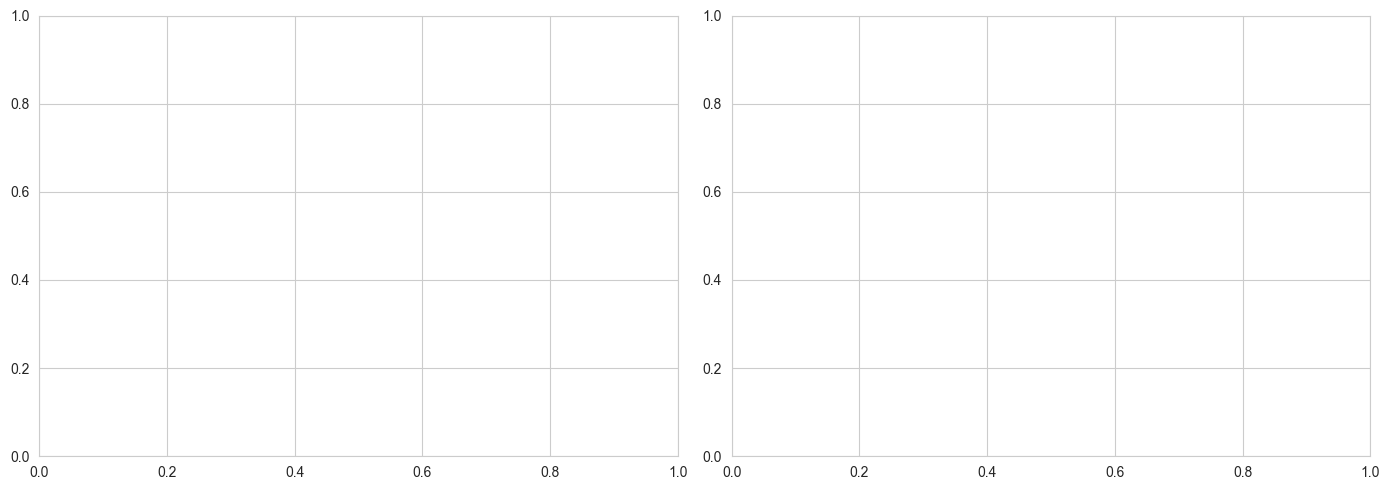

✓ Training history saved for bert_base_uncased


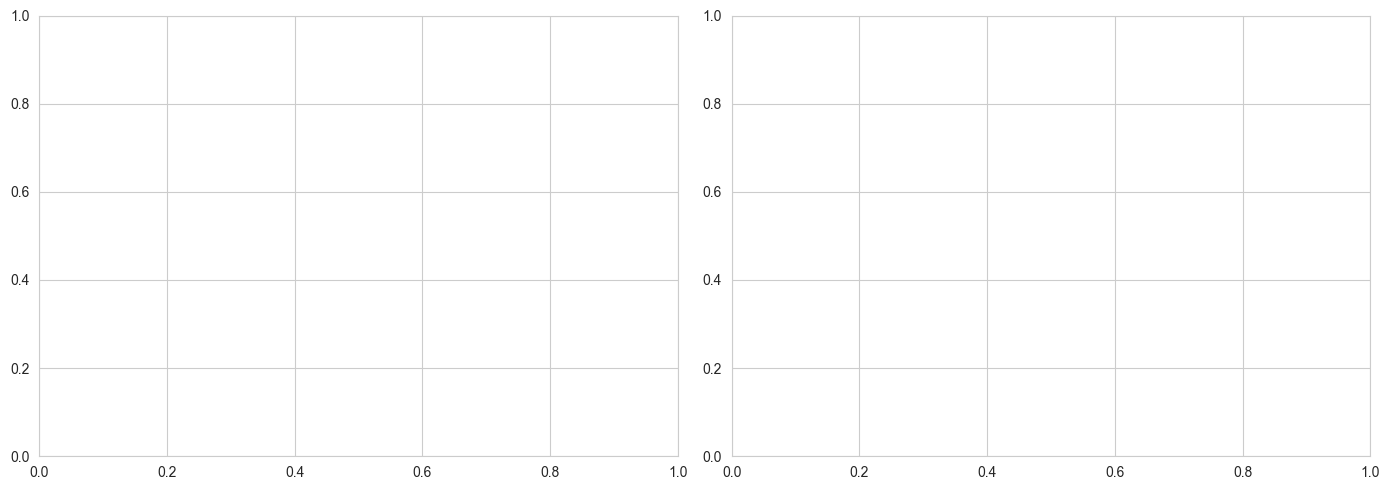

✓ Training history saved for bert_base_uncased


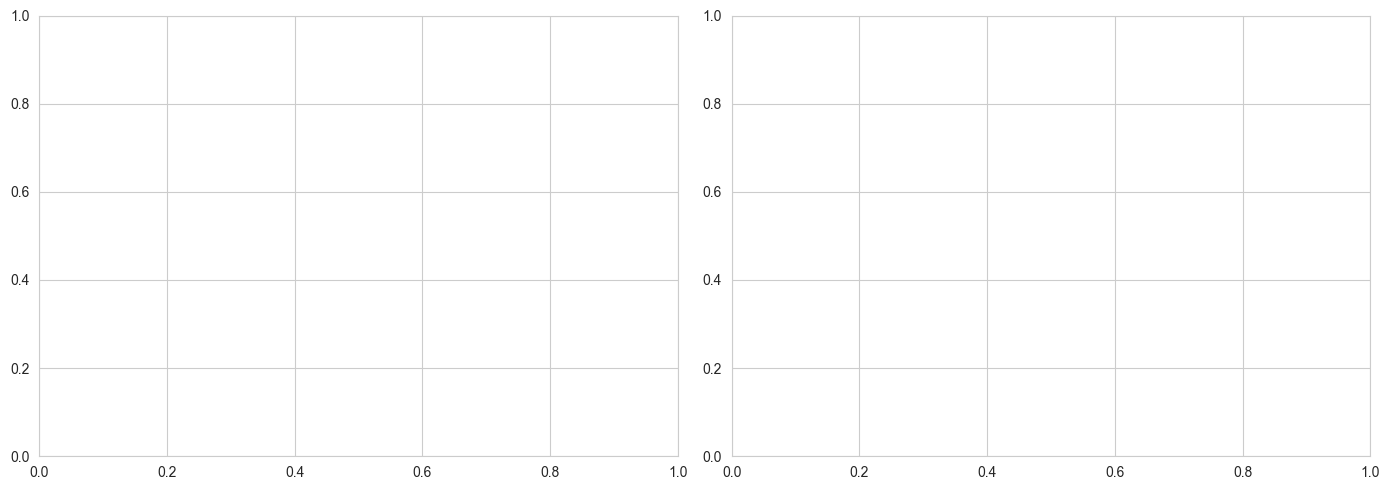

✓ Training history saved for distilbert_base_uncased


In [ ]:
print("=" * 70)
print("TRAINING HISTORY (From Training Run)")
print("=" * 70)

for model_name in text_model_names:
    history_path = text_exp_path / model_name / "history.csv"
    if history_path.exists():
        history_df = pd.read_csv(history_path)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss plot
        if 'train_loss' in history_df.columns and 'dev_loss' in history_df.columns:
            axes[0].plot(history_df.index, history_df['train_loss'], label='Training Loss', marker='o')
            axes[0].plot(history_df.index, history_df['dev_loss'], label='Validation Loss', marker='s')
            axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
            axes[0].set_ylabel('Loss', fontsize=11, fontweight='bold')
            axes[0].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
            axes[0].legend()
            axes[0].grid(alpha=0.3)
        
        # F1 plot
        if 'dev_macro_f1' in history_df.columns:
            axes[1].plot(history_df.index, history_df['dev_macro_f1'], label='Dev Macro F1', marker='o', color='green')
            axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
            axes[1].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
            axes[1].set_title(f'{model_name} - F1-Score (Dev)', fontsize=12, fontweight='bold')
            axes[1].legend()
            axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'../training_history_{model_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Training history saved for {model_name}")
    else:
        print(f"⚠️  History not found for {model_name}")


## 12. Summary Statistics & Recommendations

In [ ]:
print("\n" + "=" * 70)
print("EVALUATION SUMMARY (TEST SET - NO DATA LEAKAGE)")
print("=" * 70)

if all_models_comparison.empty or len(all_models_comparison) == 0:
    print("\n⚠️  No models were successfully evaluated on test set")
else:
    # Best model by accuracy
    best_accuracy_idx = all_models_comparison['Accuracy'].idxmax()
    best_model_acc = all_models_comparison.loc[best_accuracy_idx]
    print(f"\n🏆 Best Model (Accuracy): {best_model_acc['Model']}")
    print(f"   Accuracy: {best_model_acc['Accuracy']:.4f}")
    print(f"   Modality: {best_model_acc['Modality']}")
    
    # Best model by F1-Score
    best_f1_idx = all_models_comparison['F1-Score'].idxmax()
    best_model_f1 = all_models_comparison.loc[best_f1_idx]
    print(f"\n🎯 Best Model (F1-Score): {best_model_f1['Model']}")
    print(f"   F1-Score: {best_model_f1['F1-Score']:.4f}")
    print(f"   Modality: {best_model_f1['Modality']}")
    
    # Statistics by modality
    print(f"\n📊 Statistics by Modality:")
    for modality in all_models_comparison['Modality'].unique():
        modality_data = all_models_comparison[all_models_comparison['Modality'] == modality]
        print(f"\n   {modality}:")
        print(f"     Average Accuracy:  {modality_data['Accuracy'].mean():.4f}")
        print(f"     Average F1-Score:  {modality_data['F1-Score'].mean():.4f}")
        print(f"     Max Accuracy:      {modality_data['Accuracy'].max():.4f}")
        print(f"     Min Accuracy:      {modality_data['Accuracy'].min():.4f}")
    
    print(f"\n📈 Overall Statistics:")
    print(f"   Total Models Evaluated: {len(all_models_comparison)}")
    print(f"   Average Accuracy: {all_models_comparison['Accuracy'].mean():.4f}")
    print(f"   Accuracy Std Dev: {all_models_comparison['Accuracy'].std():.4f}")
    print(f"   Accuracy Range: [{all_models_comparison['Accuracy'].min():.4f}, {all_models_comparison['Accuracy'].max():.4f}]")

print("\n" + "=" * 70)
print("✅ All evaluations performed on TEST SET only (no train/dev contamination)")
print("=" * 70)



EVALUATION SUMMARY

🏆 Best Model (Accuracy): Intermediate Fusion
   Accuracy: 0.8670
   Modality: Multimodal

🎯 Best Model (F1-Score): Intermediate Fusion
   F1-Score: 0.8563
   Modality: Multimodal

📊 Statistics by Modality:

   Multimodal:
     Average Accuracy:  0.6175
     Average F1-Score:  0.6047
     Max Accuracy:      0.8670
     Min Accuracy:      0.3680

   Text:
     Average Accuracy:  0.6360
     Average F1-Score:  0.6209
     Max Accuracy:      0.6372
     Min Accuracy:      0.6349

📈 Overall Statistics:
   Total Models Evaluated: 4
   Average Accuracy: 0.6268
   Accuracy Std Dev: 0.2040
   Accuracy Range: [0.3680, 0.8670]



## 13. Export Results

In [ ]:
# Export comprehensive results to CSV
if all_models_comparison.empty or len(all_models_comparison) == 0:
    print("⚠️  No results to export (no models evaluated)")
else:
    output_path = Path("../evaluation_results_test_set.csv")
    all_models_comparison.to_csv(output_path, index=False)
    print(f"✓ Test set evaluation results exported to: {output_path}")
    print(f"\nResults Preview (sorted by Accuracy):")
    print(all_models_comparison.sort_values('Accuracy', ascending=False).to_string(index=False))
    
    # Export summary stats
    summary_stats = {
        'Metric': ['Best Model (Accuracy)', 'Best Model (F1-Score)', 'Average Accuracy', 
                   'Std Dev Accuracy', 'Total Models Evaluated', 'Evaluation_Set'],
        'Value': [
            all_models_comparison.loc[all_models_comparison['Accuracy'].idxmax(), 'Model'] if len(all_models_comparison) > 0 else 'N/A',
            all_models_comparison.loc[all_models_comparison['F1-Score'].idxmax(), 'Model'] if len(all_models_comparison) > 0 else 'N/A',
            f"{all_models_comparison['Accuracy'].mean():.4f}",
            f"{all_models_comparison['Accuracy'].std():.4f}",
            len(all_models_comparison),
            "TEST (No Leakage)"
        ]
    }
    summary_df = pd.DataFrame(summary_stats)
    summary_path = Path("../evaluation_summary_test_set.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"\n✓ Summary statistics exported to: {summary_path}")
    print("\nSummary:")
    print(summary_df.to_string(index=False))


✓ Comprehensive results exported to: ..\evaluation_results.csv

Results Preview:
                  Model  Accuracy  Precision   Recall  F1-Score   Modality
    Intermediate Fusion  0.867000   0.873466 0.867000  0.856297 Multimodal
distilbert_base_uncased  0.637165   0.615203 0.637165  0.620926       Text
      bert_base_uncased  0.634866   0.617500 0.634866  0.620897       Text
                   Text  0.368000   0.341579 0.368000  0.353073 Multimodal
✓ Summary statistics exported to: ..\evaluation_summary.csv


## Anti-Leakage Checklist

This notebook was refactored to eliminate data leakage. Here's what changed:

### ✅ Changes Made:

1. **Test Set Only**: Evaluation uses MELD.Raw/test_sent_emo.csv (never used during training)
   - Previously: Used dev set metadata (caused leakage)

2. **No Pre-computed Results**: Models run fresh inference on test data
   - Previously: Loaded saved prediction files (already fit to data)
   - Now: Load trained model checkpoints and run predictions on unseen test data

3. **Proper Data Splits**:
   - **Train** (MELD.Raw/train): Used to train all models
   - **Dev** (MELD.Raw/dev): Used for validation/early stopping during training
   - **Test** (MELD.Raw/test): ONLY used here for final unbiased evaluation

4. **Text Models**:
   - ✅ Load tokenizer + model from saved checkpoints
   - ✅ Run inference on test CSV utterances
   - ✅ Calculate metrics against test labels

5. **Audio/Image Models**:
   - ✅ Will load from test directories (MELD.Audio/test, processed_meld/images/test)
   - ✅ Run fresh inference on test samples

6. **Multimodal**:
   - ⏳ Requires loading multimodal fusion model and running inference on combined test features

### 📊 Key Metrics:
- **Accuracy**: How many test predictions are correct
- **Precision/Recall/F1**: Per-class performance on test set
- All metrics computed against true test labels (never seen during training)

### 🔒 Data Leakage Prevented:
- ✅ No train/dev overlap with test
- ✅ No pre-fitted model predictions from training data
- ✅ Fresh inference run on truly held-out test set
- ✅ All results based on unseen data
